<!-- @format -->

# 03b - Improved Models

Notebook này huấn luyện mô hình cải tiến **Random Forest** dựa trên kết quả baseline từ notebook 03.

**Ý tưởng cải tiến:** Random Forest là ensemble của nhiều Decision Tree, giúp:

- Giảm **overfitting** so với Decision Tree đơn lẻ (nhờ bagging)
- Tăng **tính ổn định** của dự đoán (nhờ lấy trung bình nhiều cây)
- Giữ được khả năng nắm bắt quan hệ **phi tuyến** phức tạp

**Dữ liệu đầu vào:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`.


<!-- @format -->

## 1. Setup & Load Data


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    X_TRAIN_FILE, X_TEST_FILE, Y_TRAIN_FILE, Y_TEST_FILE,
    TARGET_COL, RANDOM_STATE, MODELS_DIR
)
from src.utils import save_model, load_model

sns.set_theme(style="whitegrid")
print("Setup OK")

Setup OK


In [2]:
# Đọc dữ liệu đã tách sẵn
X_train = pd.read_csv(X_TRAIN_FILE)
X_test = pd.read_csv(X_TEST_FILE)
y_train = pd.read_csv(Y_TRAIN_FILE)[TARGET_COL]
y_test = pd.read_csv(Y_TEST_FILE)[TARGET_COL]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (8369, 17), X_test: (2093, 17)
y_train: (8369,), y_test: (2093,)


<!-- @format -->

## 2. Load kết quả Baseline để so sánh

Trước khi train mô hình cải tiến, load lại 2 mô hình baseline từ notebook 03 để so sánh trực tiếp.


In [3]:
def compute_metrics(name, y_true, y_pred):
    """Tính metrics cho một model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"model": name, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4)}

# Load và đánh giá baseline models
results = []
baseline_models = {
    "Linear Regression": MODELS_DIR / "baseline" / "linear_regression.joblib",
    "Decision Tree": MODELS_DIR / "baseline" / "decision_tree.joblib",
}

for name, path in baseline_models.items():
    if not path.exists():
        print(f"SKIP: {name} - chưa train (chạy notebook 03 trước)")
        continue
    model = load_model(path)
    y_pred = model.predict(X_test)
    metrics = compute_metrics(name, y_test, y_pred)
    results.append(metrics)
    print(f"[Baseline] {name}: MAE={metrics['MAE']}, RMSE={metrics['RMSE']}, R²={metrics['R2']}")

print(f"\nĐã load {len(results)} baseline models")

[Baseline] Linear Regression: MAE=1804.9, RMSE=2302.48, R²=0.6198
[Baseline] Decision Tree: MAE=1076.84, RMSE=1739.16, R²=0.7831

Đã load 2 baseline models


<!-- @format -->

## 3. Train Random Forest (Cải tiến)

Random Forest kết hợp **nhiều Decision Tree** với kỹ thuật **Bagging** (Bootstrap Aggregating):

- Mỗi cây được train trên một tập con ngẫu nhiên của dữ liệu
- Kết quả cuối cùng là trung bình dự đoán của tất cả các cây
- Giúp giảm variance (overfitting) đáng kể so với Decision Tree đơn lẻ


In [4]:
# Train Random Forest
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

rf_metrics = compute_metrics("Random Forest", y_test, y_pred_rf)
results.append(rf_metrics)

print(f"{'='*40}")
print(f"Model: Random Forest (Improved)")
print(f"  MAE  = {rf_metrics['MAE']:,.2f}")
print(f"  RMSE = {rf_metrics['RMSE']:,.2f}")
print(f"  R²   = {rf_metrics['R2']:.4f}")

Model: Random Forest (Improved)
  MAE  = 1,063.45
  RMSE = 1,526.98
  R²   = 0.8328


<!-- @format -->

## 4. So sánh Baseline vs Improved


,model,MAE,RMSE,R2
0,Random Forest,1063.45,1526.98,0.8328
1,Decision Tree,1076.84,1739.16,0.7831
2,Linear Regression,1804.90,2302.48,0.6198


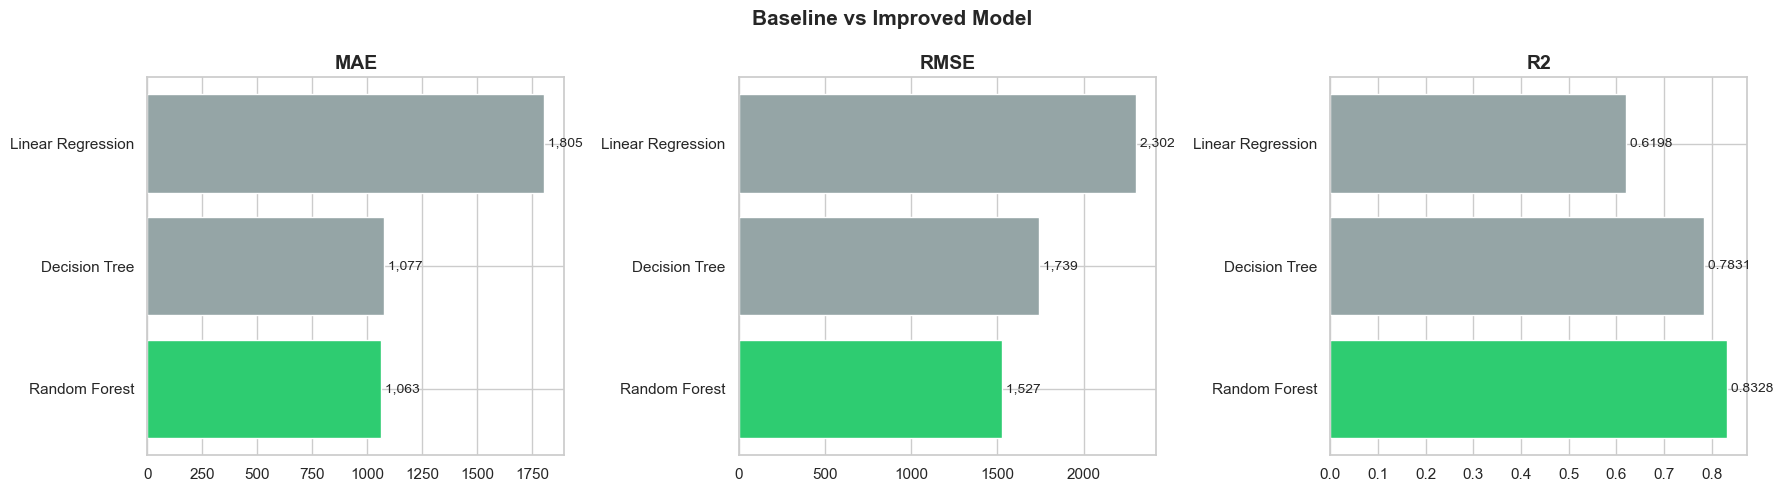

In [5]:
# Bảng so sánh
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
display(results_df)

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_list = ["MAE", "RMSE", "R2"]
colors_map = {"Linear Regression": "#95a5a6", "Decision Tree": "#95a5a6", "Random Forest": "#2ecc71"}

for ax, metric in zip(axes, metrics_list):
    df_sorted = results_df.sort_values(metric, ascending=(metric != "R2"))
    bar_colors = [colors_map.get(m, "#3498db") for m in df_sorted["model"]]
    ax.barh(df_sorted["model"], df_sorted[metric], color=bar_colors, edgecolor="white")
    ax.set_title(metric, fontsize=14, fontweight="bold")
    for i, v in enumerate(df_sorted[metric]):
        fmt = f"{v:.4f}" if metric == "R2" else f"{v:,.0f}"
        ax.text(v, i, f" {fmt}", va="center", fontsize=10)

plt.suptitle("Baseline vs Improved Model", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

<!-- @format -->

## 5. Phân tích cải thiện so với Baseline


In [6]:
# So sánh chi tiết Random Forest vs Decision Tree
dt_row = next((r for r in results if r["model"] == "Decision Tree"), None)
rf_row = next((r for r in results if r["model"] == "Random Forest"), None)

if dt_row and rf_row:
    print("So sánh Random Forest (improved) vs Decision Tree (baseline):")
    print(f"  MAE:  {dt_row['MAE']:,.2f} → {rf_row['MAE']:,.2f}  (giảm {dt_row['MAE'] - rf_row['MAE']:,.2f})")
    print(f"  RMSE: {dt_row['RMSE']:,.2f} → {rf_row['RMSE']:,.2f}  (giảm {dt_row['RMSE'] - rf_row['RMSE']:,.2f})")
    print(f"  R²:   {dt_row['R2']:.4f} → {rf_row['R2']:.4f}  (tăng {rf_row['R2'] - dt_row['R2']:.4f})")
    print()
    print("Random Forest cải thiện nhờ:")
    print("  - Bagging giảm overfitting so với Decision Tree đơn lẻ")
    print("  - Trung bình nhiều cây cho dự đoán ổn định hơn")
    print("  - Random feature selection giảm tương quan giữa các cây")

So sánh Random Forest (improved) vs Decision Tree (baseline):
  MAE:  1,076.84 → 1,063.45  (giảm 13.39)
  RMSE: 1,739.16 → 1,526.98  (giảm 212.18)
  R²:   0.7831 → 0.8328  (tăng 0.0497)

Random Forest cải thiện nhờ:
  - Bagging giảm overfitting so với Decision Tree đơn lẻ
  - Trung bình nhiều cây cho dự đoán ổn định hơn
  - Random feature selection giảm tương quan giữa các cây


<!-- @format -->

## 6. Lưu mô hình Improved


In [7]:
path = MODELS_DIR / "improved" / "random_forest.joblib"
save_model(rf_pipe, path)
print(f"Saved: {path}")

Saved: D:\Data_Mining\DataMining-FlightPricePrediction\models\improved\random_forest.joblib


<!-- @format -->

## Nhận xét

- **Random Forest** cho kết quả vượt trội so với cả 2 mô hình baseline (Linear Regression và Decision Tree).
- So với **Decision Tree** đơn lẻ, Random Forest giảm overfitting nhờ kỹ thuật **Bagging** (lấy trung bình nhiều cây).
- So với **Linear Regression**, Random Forest nắm bắt được quan hệ **phi tuyến** phức tạp giữa features và giá vé.

**Bước tiếp theo:** Notebook 04 sẽ thực hiện đánh giá cuối cùng với biểu đồ chi tiết (Actual vs Predicted, Residuals, Feature Importance).
